Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  PART 1: DATA EXPLORATION

📂 Found 4 house directories

📁 house_A: 7 experiments
📁 house_B: 9 experiments
📁 house_C: 14 experiments
📁 house_D: 8 experiments

🔧 Trying fallback strategy (no timestamp alignment)...
  ✓ house_A/fingerprint_floor: 60,120 samples
  ✓ house_A/living_1: 15,853 samples
  ✓ house_A/walking_natural: 6,004 samples
  ✓ house_A/living_3: 49,628 samples
  ✓ house_A/living_4: 10,099 samples
  ✓ house_A/living_2: 16,877 samples
  ✓ house_A/walking_rapid: 5,244 samples
  ✓ house_B/fingerprint_activity: 8,465 samples
  ✓ house_B/fingerprint_floor: 202,563 samples
  ✓ house_B/living_2: 14,208 samples
  ✓ house_B/fingerprint_rapid: 10,593 samples
  ✓ house_B/living_1: 23,011 samples
  ✓ house_B/living_4: 20,470 samples
  ✓ house_B/walking_natural: 11,259 samples
  ✓ house_B/living_3: 28,963 samples
  ✓ house_B/walking_rapid: 5,804 samples
  ✓ h

,timestamp,ap_id,wearable_id,rssi,acc1x,acc1y,acc1z,acc2x,acc2y,acc2z,...,acc4y,acc4z,acc5x,acc5y,acc5z,batterylevel,seqno,tag,house_id,experiment
0,2017-04-09T10:35:32.592Z,6,1,-55,-1.562,-1.156,0.375,-1.562,-1.156,0.406,...,-1.125,0.375,-1.594,-1.188,0.406,245,371811,0,house_A,fingerprint_floor
1,2017-04-09T10:35:32.603Z,11,1,-84,-1.562,-1.156,0.375,-1.562,-1.156,0.406,...,-1.125,0.375,-1.594,-1.188,0.406,245,371811,0,house_A,fingerprint_floor
2,2017-04-09T10:35:32.620Z,2,1,-86,-1.562,-1.156,0.375,-1.562,-1.156,0.406,...,-1.125,0.375,-1.594,-1.188,0.406,245,371811,0,house_A,fingerprint_floor
3,2017-04-09T10:35:32.623Z,9,1,-48,-1.562,-1.156,0.375,-1.562,-1.156,0.406,...,-1.125,0.375,-1.594,-1.188,0.406,245,371811,0,house_A,fingerprint_floor
4,2017-04-09T10:35:32.630Z,8,1,-71,-1.562,-1.156,0.375,-1.562,-1.156,0.406,...,-1.125,0.375,-1.594,-1.188,0.406,245,371811,0,house_A,fingerprint_floor



  FEATURE IDENTIFICATION

✓ Using 20 numeric features

Features (first 10): ['ap_id', 'wearable_id', 'rssi', 'acc1x', 'acc1y', 'acc1z', 'acc2x', 'acc2y', 'acc2z', 'acc3x']

  STATISTICAL SUMMARY

📈 Feature Statistics:
                  mean        std    min     max
ap_id         5.963346   3.242902    1.0  11.000
wearable_id   1.000000   0.000000    1.0   1.000
rssi        -74.775766  13.087103 -110.0  -8.000
acc1x        -0.955029   1.185374   -4.0   3.969
acc1y        -0.904708   0.663019   -4.0   3.969
acc1z        -0.559692   0.759522   -4.0   3.969
acc2x        -0.954844   1.185509   -4.0   3.969
acc2y        -0.904400   0.662343   -4.0   3.969
acc2z        -0.560325   0.758331   -4.0   3.969
acc3x        -0.955189   1.185132   -4.0   3.969

🏷️  Labels:
   Unique locations: 82
   Total samples: 1,586,880

   Top 10:
    1. 16                             128,775 (  8.1%)
    2. 17                             74,006 (  4.7%)
    3. 18                             66,964 (  4.2%)
  

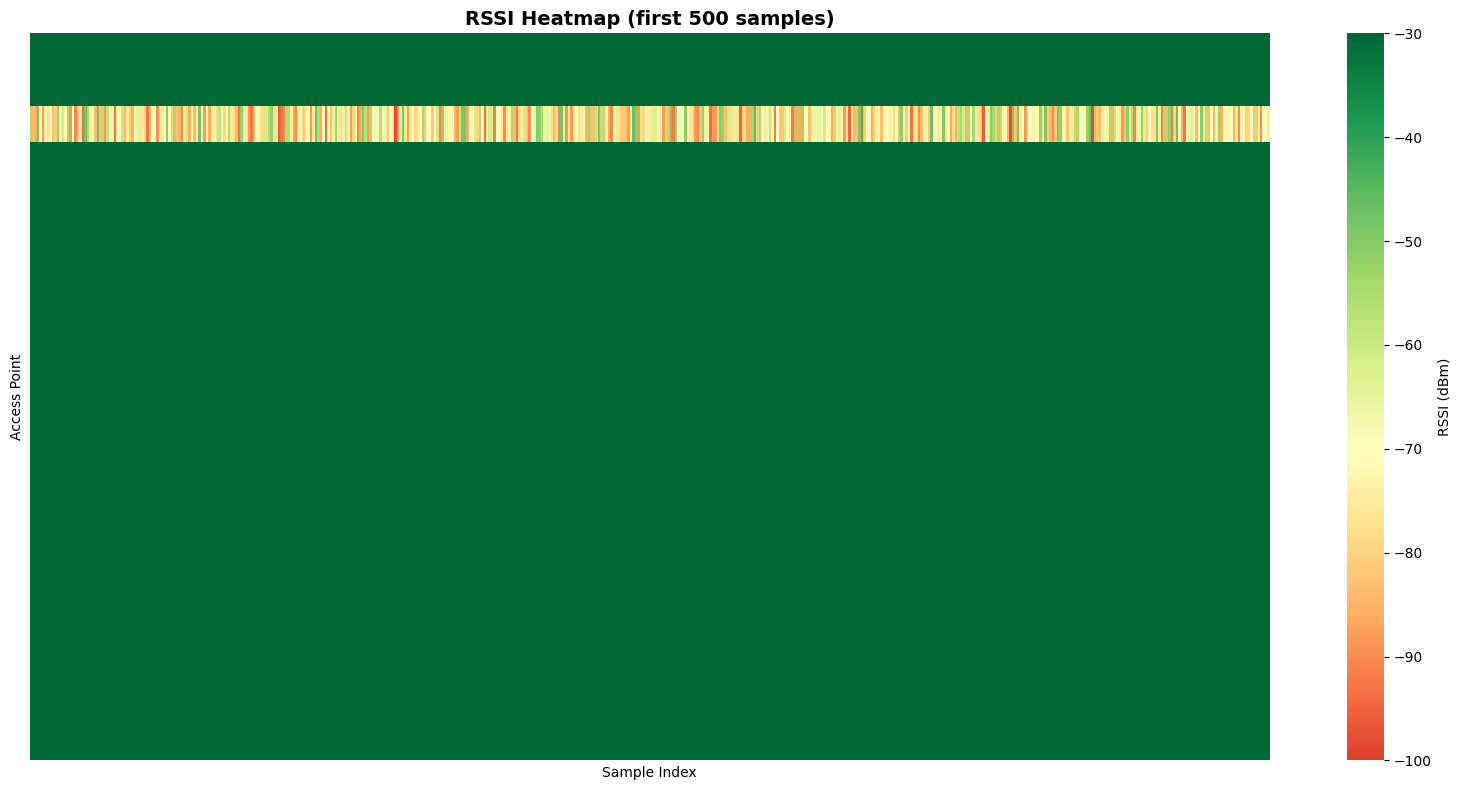


📊 2. RSSI Analysis...
   ✓ Saved: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/exploration_rssi_analysis.png


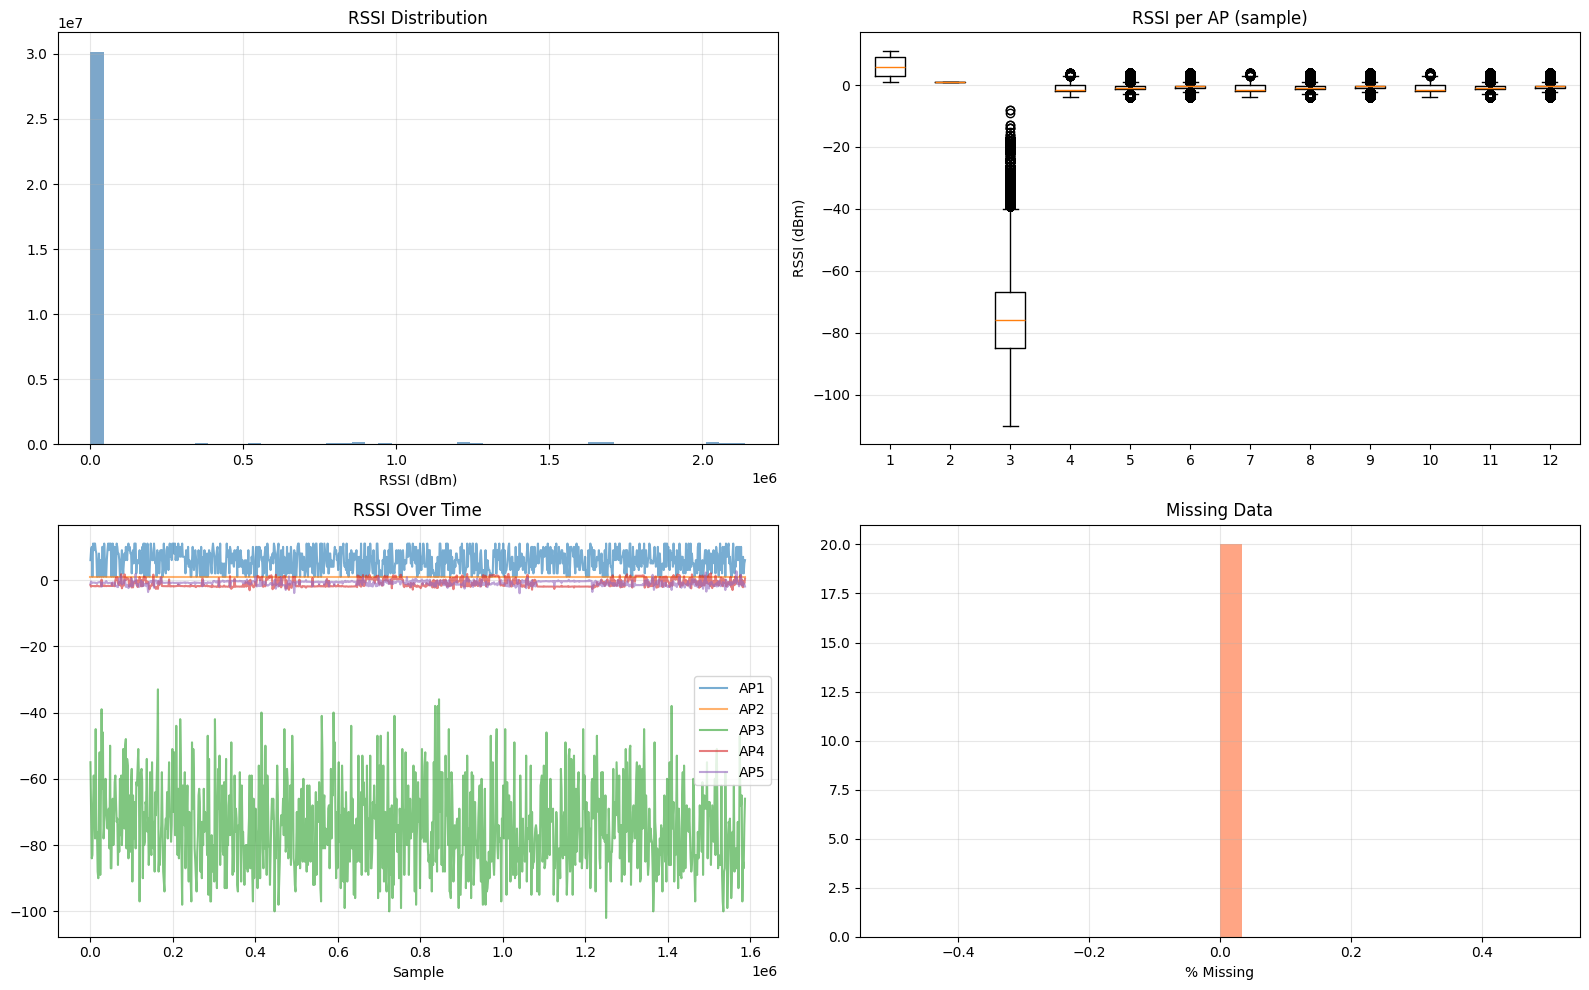


📊 3. Location Distribution...
   ✓ Saved: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/exploration_location_distribution.png


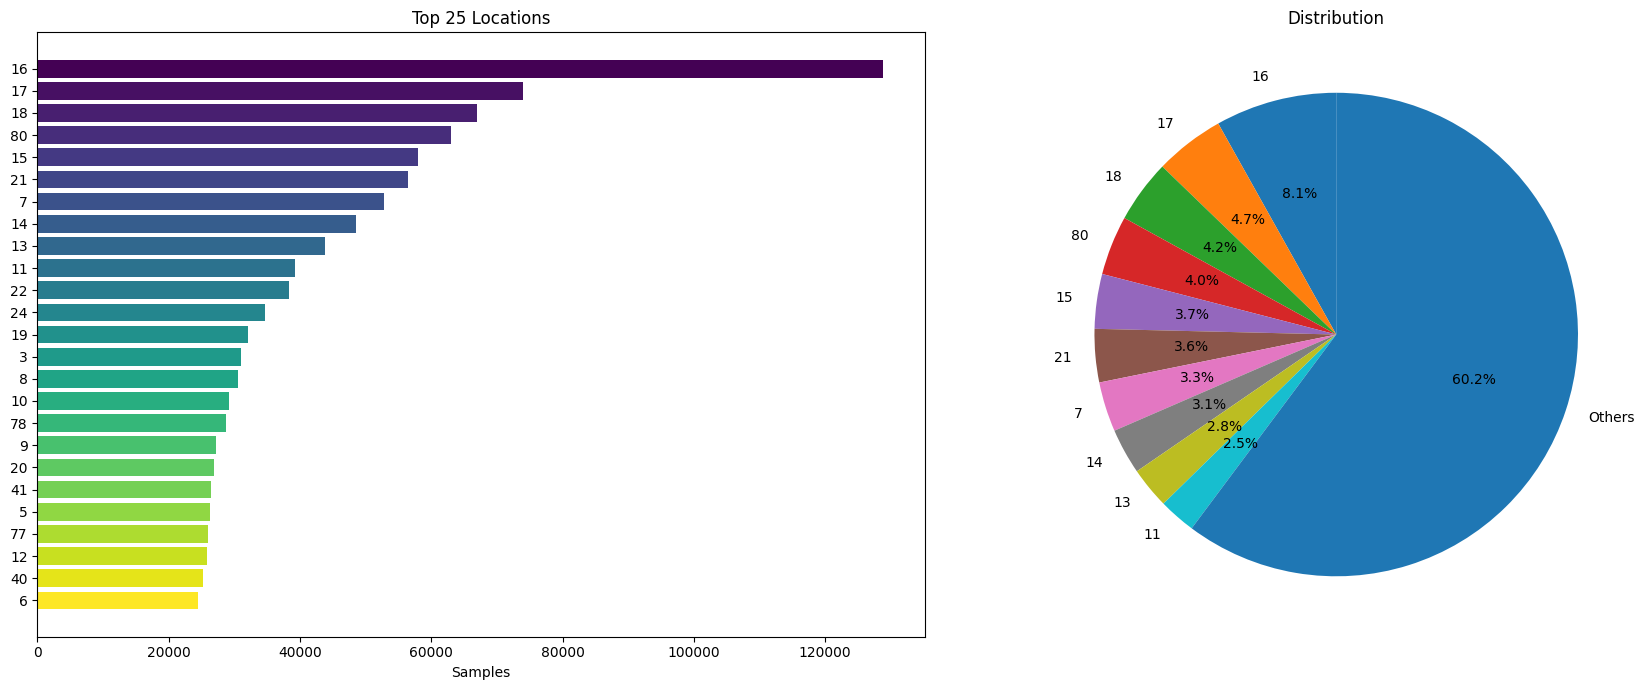


📊 4. House Comparison...
   ✓ Saved: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/exploration_house_comparison.png


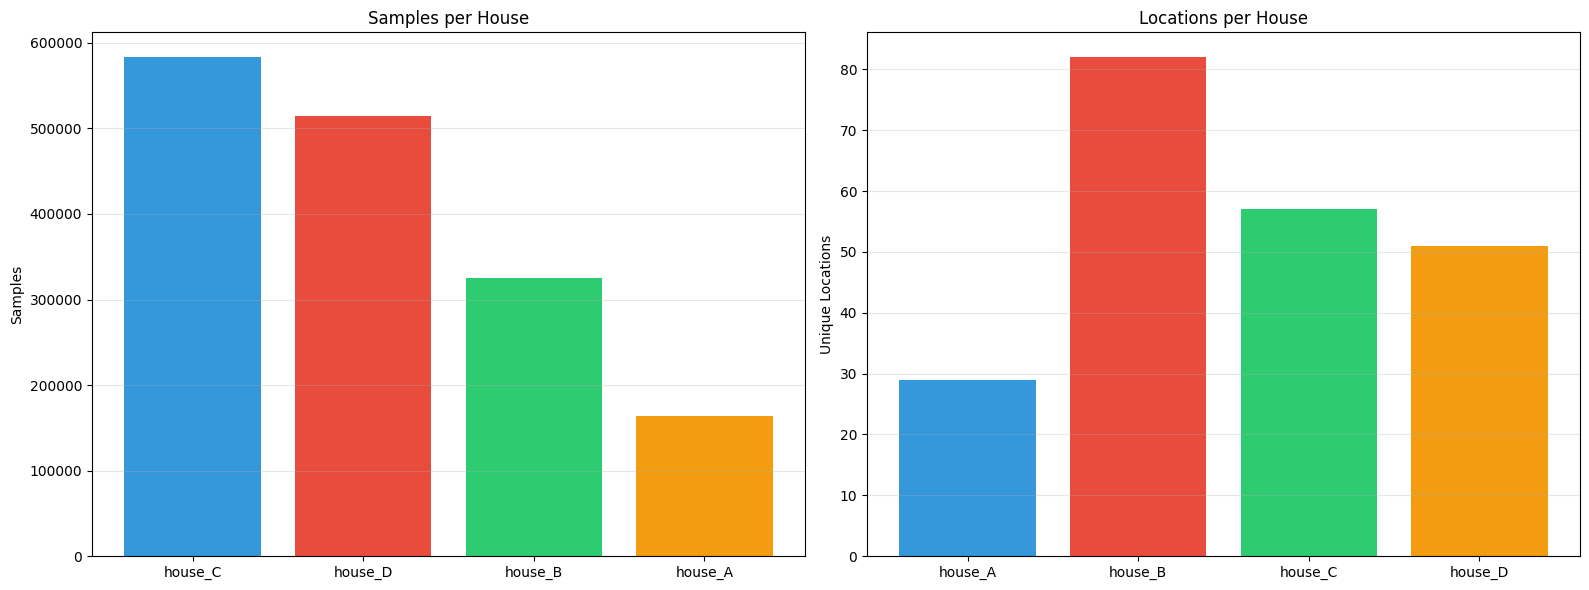


📊 5. Saving Summary...
   ✓ Saved: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/exploration_summary.json
   ✓ Saved: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/exploration_label_counts.csv
   ✓ Saved: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/preprocessed_data.pkl (309.05 MB)

  ✅ DATA EXPLORATION COMPLETE!

📁 Output: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs

📊 Files:
   • exploration_rssi_heatmap.png
   • exploration_rssi_analysis.png
   • exploration_location_distribution.png
   • exploration_house_comparison.png
   • exploration_summary.json
   • exploration_label_counts.csv
   • preprocessed_data.pkl

🚀 Ready for PART 2!


In [23]:

# TinyML Indoor Localisation - COMPLETE PIPELINE
# PART 1: DATA EXPLORATION


from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/CSE499A/residential_wearable_data"
OUTPUT_DIR = "/content/drive/MyDrive/CSE499A/residential_wearable_data/outputs"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

!pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib seaborn tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from datetime import datetime

print("="*70)
print("  PART 1: DATA EXPLORATION")
print("="*70)


# 1) DATA LOADING FUNCTION (FIXED)

def load_residential_dataset(data_root):
    """Load all rx_wearable_data.dat and tag_annotations.dat files"""
    all_data = []
    house_dirs = glob.glob(os.path.join(data_root, "house_*"))

    if len(house_dirs) == 0:
        print(f"ERROR: No house directories found in {data_root}")
        return None

    print(f"\n📂 Found {len(house_dirs)} house directories\n")

    for house_dir in sorted(house_dirs):
        house_id = os.path.basename(house_dir)
        experiments_root = os.path.join(house_dir, "experiments")

        if not os.path.exists(experiments_root):
            print(f"  ⚠️  {house_id}: No 'experiments' folder, skipping")
            continue

        exp_dirs = [d for d in glob.glob(os.path.join(experiments_root, "*"))
                   if os.path.isdir(d)]

        print(f"📁 {house_id}: {len(exp_dirs)} experiments")

        for exp_dir in sorted(exp_dirs):
            exp_name = os.path.basename(exp_dir)
            wearable_file = os.path.join(exp_dir, "rx_wearable_data.dat")
            annotation_file = os.path.join(exp_dir, "tag_annotations.dat")

            if not os.path.exists(wearable_file):
                continue

            try:
                wearable_df = pd.read_csv(wearable_file)

                if not os.path.exists(annotation_file):
                    continue

                annotations_df = pd.read_csv(annotation_file)

                # Find timestamp column
                timestamp_col = None
                for col in wearable_df.columns:
                    if 'time' in col.lower():
                        timestamp_col = col
                        break
                if timestamp_col is None:
                    timestamp_col = wearable_df.columns[0]

                # Parse timestamps
                try:
                    wearable_df['timestamp'] = pd.to_datetime(wearable_df[timestamp_col], unit='s', errors='coerce')
                except:
                    wearable_df['timestamp'] = pd.to_datetime(wearable_df[timestamp_col], errors='coerce')

                # Same for annotations
                anno_time_col = None
                for col in annotations_df.columns:
                    if 'time' in col.lower():
                        anno_time_col = col
                        break
                if anno_time_col is None:
                    anno_time_col = annotations_df.columns[0]

                try:
                    annotations_df['timestamp'] = pd.to_datetime(annotations_df[anno_time_col], unit='s', errors='coerce')
                except:
                    annotations_df['timestamp'] = pd.to_datetime(annotations_df[anno_time_col], errors='coerce')

                # Remove null timestamps
                wearable_df = wearable_df.dropna(subset=['timestamp'])
                annotations_df = annotations_df.dropna(subset=['timestamp'])

                if len(wearable_df) == 0 or len(annotations_df) == 0:
                    continue

                # Find tag column
                tag_col = None
                for col in annotations_df.columns:
                    if 'tag' in col.lower() or 'label' in col.lower() or 'location' in col.lower():
                        tag_col = col
                        break
                if tag_col is None:
                    for col in annotations_df.columns:
                        if col != 'timestamp' and annotations_df[col].dtype == 'object':
                            tag_col = col
                            break
                if tag_col is None:
                    continue

                # Sort and merge
                wearable_df = wearable_df.sort_values('timestamp').reset_index(drop=True)
                annotations_df = annotations_df.sort_values('timestamp').reset_index(drop=True)

                merged_df = pd.merge_asof(
                    wearable_df,
                    annotations_df[['timestamp', tag_col]],
                    on='timestamp',
                    direction='nearest',
                    tolerance=pd.Timedelta('5s')
                )

                if tag_col != 'tag':
                    merged_df = merged_df.rename(columns={tag_col: 'tag'})

                merged_df = merged_df.dropna(subset=['tag'])

                if len(merged_df) == 0:
                    continue

                merged_df['house_id'] = house_id
                merged_df['experiment'] = exp_name

                all_data.append(merged_df)
                print(f"  ✓ {exp_name}: {len(merged_df):,} labeled samples")

            except Exception as e:
                print(f"  ❌ {exp_name}: {str(e)}")
                continue

    if len(all_data) == 0:
        print("\n🔧 Trying fallback strategy (no timestamp alignment)...")

        # Fallback without timestamp alignment
        for house_dir in sorted(house_dirs):
            house_id = os.path.basename(house_dir)
            experiments_root = os.path.join(house_dir, "experiments")

            if not os.path.exists(experiments_root):
                continue

            exp_dirs = [d for d in glob.glob(os.path.join(experiments_root, "*"))
                       if os.path.isdir(d)]

            for exp_dir in exp_dirs:
                exp_name = os.path.basename(exp_dir)
                wearable_file = os.path.join(exp_dir, "rx_wearable_data.dat")
                annotation_file = os.path.join(exp_dir, "tag_annotations.dat")

                if not os.path.exists(wearable_file) or not os.path.exists(annotation_file):
                    continue

                try:
                    wearable_df = pd.read_csv(wearable_file)
                    annotations_df = pd.read_csv(annotation_file)

                    tag_col = None
                    for col in annotations_df.columns:
                        if 'tag' in col.lower() or 'label' in col.lower():
                            tag_col = col
                            break
                    if tag_col is None:
                        for col in annotations_df.columns:
                            if annotations_df[col].dtype == 'object':
                                tag_col = col
                                break
                    if tag_col is None:
                        continue

                    # Index-based alignment
                    if len(wearable_df) >= len(annotations_df):
                        indices = np.linspace(0, len(annotations_df)-1, len(wearable_df)).astype(int)
                        wearable_df['tag'] = annotations_df[tag_col].iloc[indices].values
                    else:
                        wearable_df['tag'] = annotations_df[tag_col].iloc[:len(wearable_df)].values

                    wearable_df = wearable_df.dropna(subset=['tag'])

                    if len(wearable_df) == 0:
                        continue

                    wearable_df['house_id'] = house_id
                    wearable_df['experiment'] = exp_name

                    all_data.append(wearable_df)
                    print(f"  ✓ {house_id}/{exp_name}: {len(wearable_df):,} samples")

                except Exception as e:
                    continue

    if len(all_data) == 0:
        return None

    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"\n{'='*70}")
    print(f"✅ SUCCESS: {len(combined_df):,} samples from {len(all_data)} experiments")
    print(f"{'='*70}\n")

    return combined_df

# Load data
df = load_residential_dataset(DATA_ROOT)

if df is None:
    raise SystemExit("❌ Dataset loading failed")


# 2) DATA INFO

print("\n" + "="*70)
print("  DATASET OVERVIEW")
print("="*70)

print(f"\n📊 Shape: {df.shape}")
print(f"📊 Columns: {list(df.columns)[:15]}...")
print(f"📊 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nFirst 5 rows:")
display(df.head())


# 3) FEATURE IDENTIFICATION
label_col = 'tag'
time_col = 'timestamp' if 'timestamp' in df.columns else None

print("\n" + "="*70)
print("  FEATURE IDENTIFICATION")
print("="*70)

if 'ap_address' in df.columns and 'rssi' in df.columns:
    print("\n🔍 Long format detected - pivoting...")

    if time_col:
        df['row_id'] = df.groupby([time_col, label_col, 'house_id', 'experiment']).ngroup()
        index_cols = ['row_id', time_col, label_col, 'house_id', 'experiment']
    else:
        df['row_id'] = df.groupby([label_col, 'house_id', 'experiment']).cumcount()
        index_cols = ['row_id', label_col, 'house_id', 'experiment']

    rssi_pivot = df.pivot_table(
        index=index_cols,
        columns='ap_address',
        values='rssi',
        aggfunc='first'
    ).reset_index()

    rssi_pivot = rssi_pivot.drop('row_id', axis=1)
    rssi_pivot.columns.name = None

    ap_cols = [col for col in rssi_pivot.columns
               if col not in [time_col, label_col, 'house_id', 'experiment']]

    rssi_pivot[ap_cols] = rssi_pivot[ap_cols].fillna(-120)

    df = rssi_pivot
    feature_cols = ap_cols

    print(f"   ✓ Shape: {df.shape}")
    print(f"   ✓ Features: {len(feature_cols)}")
else:
    feature_cols = [c for c in df.columns
                   if np.issubdtype(df[c].dtype, np.number)
                   and c not in [label_col, time_col, 'house_id', 'experiment']]
    print(f"\n✓ Using {len(feature_cols)} numeric features")

if len(feature_cols) == 0:
    raise SystemExit("❌ No feature columns found!")

print(f"\nFeatures (first 10): {feature_cols[:10]}")

# 4) STATISTICS

print("\n" + "="*70)
print("  STATISTICAL SUMMARY")
print("="*70)

print(f"\n📈 Feature Statistics:")
print(df[feature_cols].describe().T[['mean', 'std', 'min', 'max']].head(10))

labels = df[label_col].astype(str)
label_counts = labels.value_counts()

print(f"\n🏷️  Labels:")
print(f"   Unique locations: {labels.nunique()}")
print(f"   Total samples: {len(labels):,}")
print(f"\n   Top 10:")
for i, (loc, count) in enumerate(label_counts.head(10).items(), 1):
    print(f"   {i:2d}. {loc:<30} {count:>6,} ({count/len(labels)*100:>5.1f}%)")

imbalance = label_counts.max() / label_counts.min()
print(f"\n   Imbalance: {imbalance:.2f}:1 {'⚠️ High!' if imbalance > 10 else '✓'}")

print(f"\n🏠 Houses:")
for house, count in df['house_id'].value_counts().items():
    print(f"   {house}: {count:>6,} ({count/len(df)*100:>5.1f}%)")

# 5) VISUALIZATIONS

print("\n" + "="*70)
print("  GENERATING VISUALIZATIONS")
print("="*70)

# 1. RSSI Heatmap
print("\n📊 1. RSSI Heatmap...")
N = min(500, len(df))
plt.figure(figsize=(16, 8))
sns.heatmap(df[feature_cols].iloc[:N].T, cmap="RdYlGn", center=-70,
            cbar_kws={'label': 'RSSI (dBm)'}, vmin=-100, vmax=-30,
            xticklabels=False, yticklabels=False)
plt.title(f"RSSI Heatmap (first {N} samples)", fontsize=14, fontweight='bold')
plt.xlabel("Sample Index")
plt.ylabel("Access Point")
plt.tight_layout()
heatmap_path = os.path.join(OUTPUT_DIR, "exploration_rssi_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
print(f"   ✓ Saved: {heatmap_path}")
plt.show()

# 2. RSSI Analysis
print("\n📊 2. RSSI Analysis...")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(df[feature_cols].values.flatten(), bins=50, color='steelblue', alpha=0.7)
axes[0, 0].set_title("RSSI Distribution")
axes[0, 0].set_xlabel("RSSI (dBm)")
axes[0, 0].grid(alpha=0.3)

sample_features = feature_cols[:min(12, len(feature_cols))]
axes[0, 1].boxplot([df[col].values for col in sample_features])
axes[0, 1].set_title(f"RSSI per AP (sample)")
axes[0, 1].set_ylabel("RSSI (dBm)")
axes[0, 1].grid(axis='y', alpha=0.3)

sample_idx = np.linspace(0, len(df)-1, min(1000, len(df))).astype(int)
for i, col in enumerate(feature_cols[:5]):
    axes[1, 0].plot(sample_idx, df[col].iloc[sample_idx], alpha=0.6, label=f"AP{i+1}")
axes[1, 0].set_title("RSSI Over Time")
axes[1, 0].set_xlabel("Sample")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

missing_pct = ((df[feature_cols] == -120) | df[feature_cols].isna()).mean() * 100
axes[1, 1].hist(missing_pct, bins=30, color='coral', alpha=0.7)
axes[1, 1].set_title("Missing Data")
axes[1, 1].set_xlabel("% Missing")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
analysis_path = os.path.join(OUTPUT_DIR, "exploration_rssi_analysis.png")
plt.savefig(analysis_path, dpi=150)
print(f"   ✓ Saved: {analysis_path}")
plt.show()

# 3. Location Distribution
print("\n📊 3. Location Distribution...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_labels = label_counts.head(25)
axes[0].barh(range(len(top_labels)), top_labels.values,
             color=plt.cm.viridis(np.linspace(0, 1, len(top_labels))))
axes[0].set_yticks(range(len(top_labels)))
axes[0].set_yticklabels(top_labels.index)
axes[0].set_xlabel("Samples")
axes[0].set_title("Top 25 Locations")
axes[0].invert_yaxis()

top_10 = label_counts.head(10)
others = label_counts.iloc[10:].sum()
axes[1].pie(list(top_10.values) + [others],
           labels=list(top_10.index) + ['Others'],
           autopct='%1.1f%%', startangle=90)
axes[1].set_title("Distribution")

plt.tight_layout()
location_path = os.path.join(OUTPUT_DIR, "exploration_location_distribution.png")
plt.savefig(location_path, dpi=150)
print(f"   ✓ Saved: {location_path}")
plt.show()

# 4. House Comparison
print("\n📊 4. House Comparison...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

house_counts = df['house_id'].value_counts()
axes[0].bar(house_counts.index, house_counts.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_title("Samples per House")
axes[0].set_ylabel("Samples")
axes[0].grid(axis='y', alpha=0.3)

location_per_house = df.groupby('house_id')[label_col].nunique()
axes[1].bar(location_per_house.index, location_per_house.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_title("Locations per House")
axes[1].set_ylabel("Unique Locations")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
house_path = os.path.join(OUTPUT_DIR, "exploration_house_comparison.png")
plt.savefig(house_path, dpi=150)
print(f"   ✓ Saved: {house_path}")
plt.show()

# 6) SAVE SUMMARY (FIXED)

print("\n📊 5. Saving Summary...")

def convert_to_native(obj):
    """Convert numpy/pandas types to native Python types"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(item) for item in obj]
    return obj

summary = {
    "timestamp": datetime.now().isoformat(),
    "dataset": {
        "total_samples": int(len(df)),
        "num_features": int(len(feature_cols)),
        "num_houses": int(df['house_id'].nunique()),
        "num_experiments": int(df['experiment'].nunique()),
        "num_locations": int(labels.nunique())
    },
    "rssi_stats": {
        "mean": float(df[feature_cols].values.mean()),
        "std": float(df[feature_cols].values.std()),
        "min": float(df[feature_cols].values.min()),
        "max": float(df[feature_cols].values.max())
    },
    "class_distribution": {
        "imbalance_ratio": float(imbalance),
        "top_5": {str(k): int(v) for k, v in label_counts.head(5).items()}
    }
}

summary = convert_to_native(summary)

summary_path = os.path.join(OUTPUT_DIR, "exploration_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"   ✓ Saved: {summary_path}")

label_counts_df = pd.DataFrame({
    "location": label_counts.index,
    "count": label_counts.values,
    "percentage": (label_counts.values / label_counts.sum()) * 100
})
counts_path = os.path.join(OUTPUT_DIR, "exploration_label_counts.csv")
label_counts_df.to_csv(counts_path, index=False)
print(f"   ✓ Saved: {counts_path}")

preprocessed_path = os.path.join(OUTPUT_DIR, "preprocessed_data.pkl")
df.to_pickle(preprocessed_path)
print(f"   ✓ Saved: {preprocessed_path} ({os.path.getsize(preprocessed_path)/1024**2:.2f} MB)")

print("\n" + "="*70)
print("  ✅ DATA EXPLORATION COMPLETE!")
print("="*70)
print(f"\n📁 Output: {OUTPUT_DIR}")
print("\n📊 Files:")
print("   • exploration_rssi_heatmap.png")
print("   • exploration_rssi_analysis.png")
print("   • exploration_location_distribution.png")
print("   • exploration_house_comparison.png")
print("   • exploration_summary.json")
print("   • exploration_label_counts.csv")
print("   • preprocessed_data.pkl")

print("\n🚀 Ready for PART 2!")
print("="*70)


  PART 2: MODEL TRAINING PIPELINE

📂 Loading: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/preprocessed_data.pkl
✓ Shape: (1586880, 24)
✓ Features: 20
✓ Classes: 82

🖥️  Device: cuda

  PREPROCESSING

🔧 Creating windows...
   Window: 444 rows | Stride: 222
   ✓ Shape: (7147, 444, 20)

🔧 Imputing & scaling...

🔧 Encoding labels...
   ✓ 82 classes

🔧 Splitting...
   ✓ Train:  5,359
   ✓ Val:      715
   ✓ Test:   1,073

  MODELS

📊 MLP:  1,150,354 params
📊 LSTM: 60,626 params

  TRAINING

🚀 Training MLP...
----------------------------------------------------------------------
   Epoch  1/25 | Loss: 4.1556 | F1: 0.0793 | Acc: 0.1287
   Epoch  5/25 | Loss: 3.5022 | F1: 0.0806 | Acc: 0.1329
   Epoch 10/25 | Loss: 3.2249 | F1: 0.0920 | Acc: 0.1329
   Epoch 15/25 | Loss: 3.0089 | F1: 0.1162 | Acc: 0.1510
   Epoch 20/25 | Loss: 2.7867 | F1: 0.1124 | Acc: 0.1483
   Epoch 25/25 | Loss: 2.6280 | F1: 0.1270 | Acc: 0.1455
---------------------------------------------------------

/tmp/ipython-input-4018923070.py:340: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_mlp = torch.quantization.quantize_dynamic(model_mlp_trained.cpu(), {nn.Linear}, torch.qint8)
/tmp/ipython-input-4018923070.py:341: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao


🎯 Quantized:
   MLP:  F1=0.1029 (Δ+0.0013)
   LSTM: F1=0.0652 (Δ+0.0026)

📊 Generating plots...


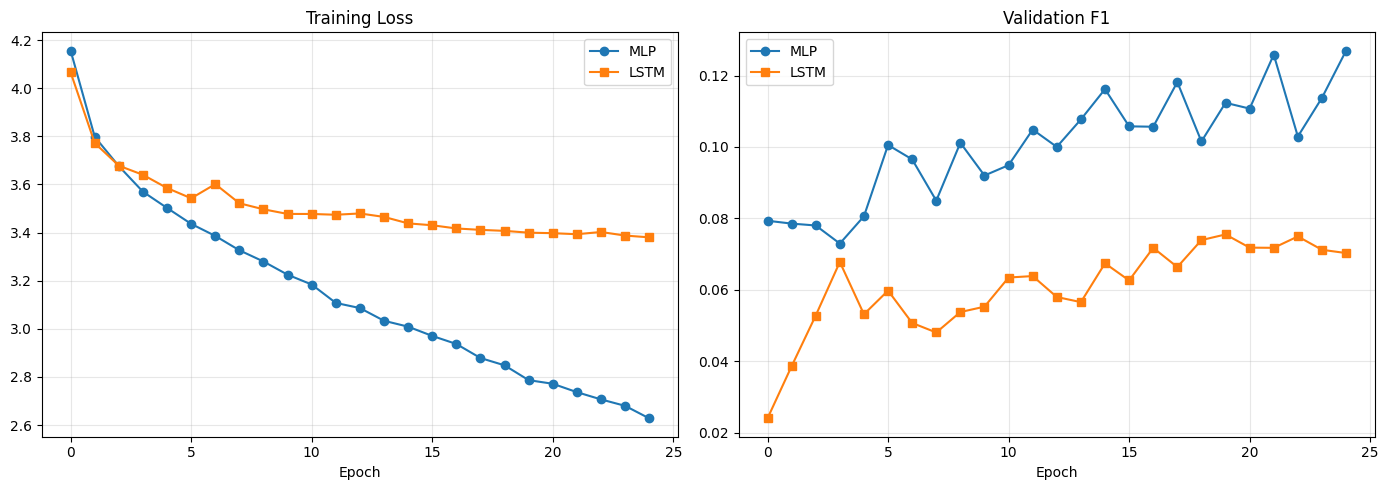

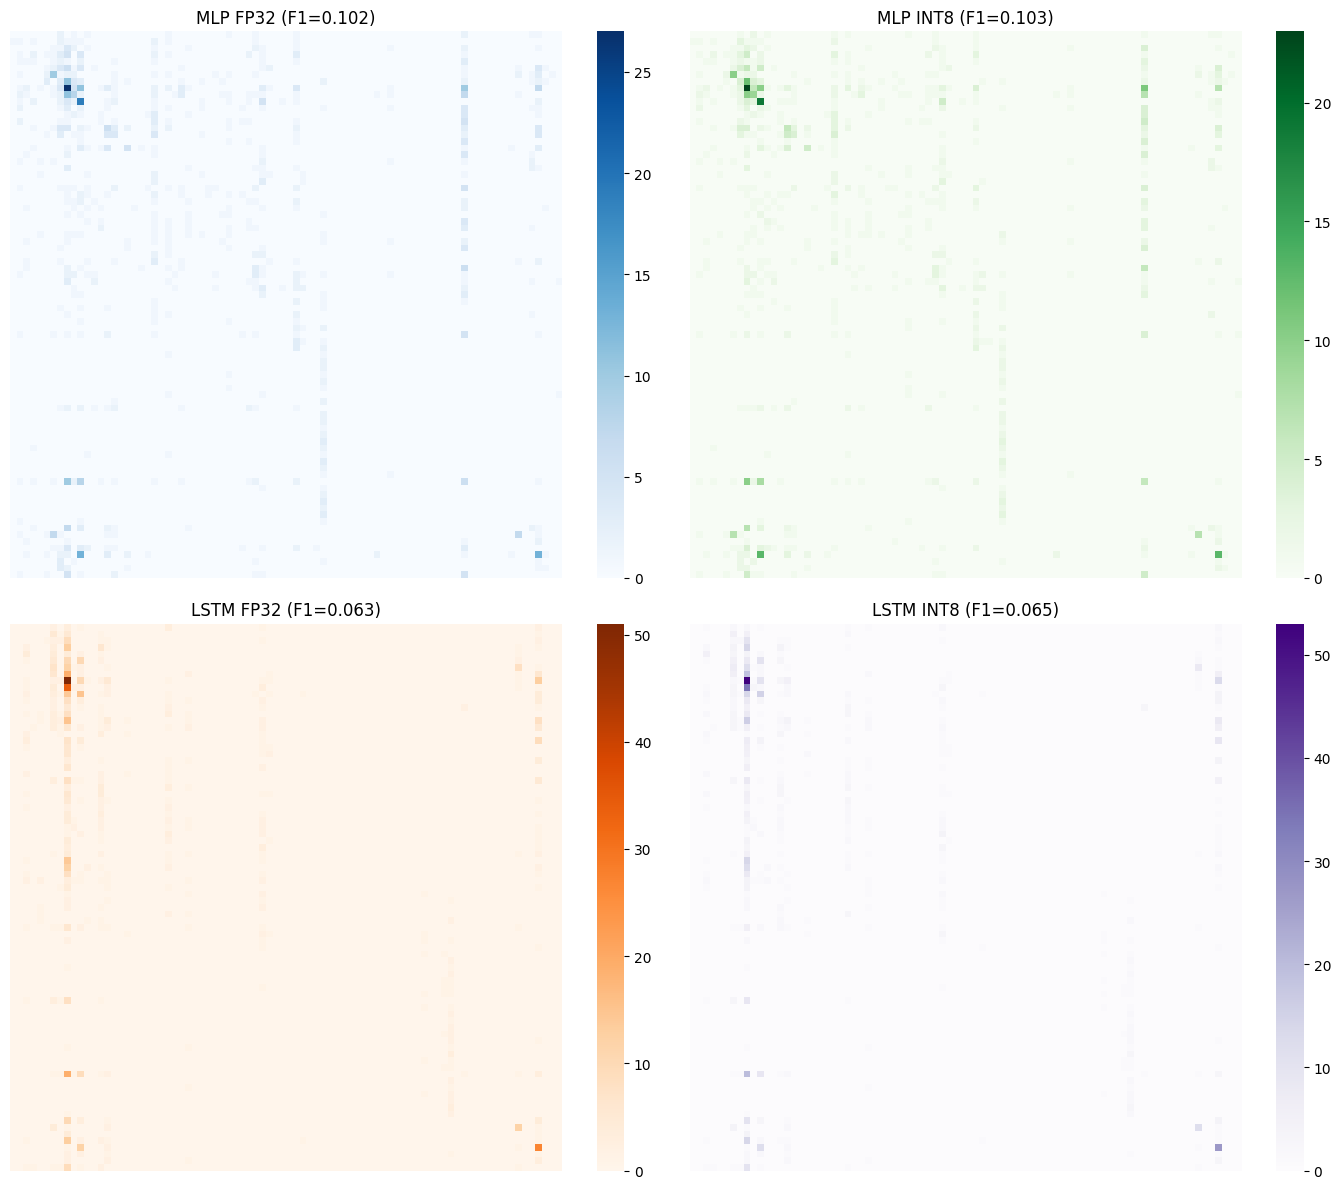


  ✅ COMPLETE!

Model        F1       Size (KB) 
------------------------------
MLP FP32     0.1016   4496.7    
MLP INT8     0.1029   1129.1    
LSTM FP32    0.0626   239.6     
LSTM INT8    0.0652   67.8      


In [24]:

# PART 2: MODEL TRAINING PIPELINE (FIXED)


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

print("="*70)
print("  PART 2: MODEL TRAINING PIPELINE")
print("="*70)

# 1) LOAD PREPROCESSED DATA

OUTPUT_DIR = "/content/drive/MyDrive/CSE499A/residential_wearable_data/outputs"
preprocessed_path = os.path.join(OUTPUT_DIR, "preprocessed_data.pkl")

if not os.path.exists(preprocessed_path):
    raise FileNotFoundError(f"❌ Run PART 1 first!")

print(f"\n📂 Loading: {preprocessed_path}")
df = pd.read_pickle(preprocessed_path)

label_col = 'tag'
time_col = 'timestamp' if 'timestamp' in df.columns else None
feature_cols = [c for c in df.columns
               if np.issubdtype(df[c].dtype, np.number)
               and c not in [label_col, time_col, 'house_id', 'experiment']]

print(f"✓ Shape: {df.shape}")
print(f"✓ Features: {len(feature_cols)}")
print(f"✓ Classes: {df[label_col].nunique()}")


# 2) CONFIG

CONFIG = {
    "WINDOW_SECONDS": 4,
    "WINDOW_STRIDE": 2,
    "RANDOM_SEED": 42,
    "BATCH_SIZE": 64,
    "NUM_EPOCHS": 25,
    "LEARNING_RATE": 1e-3,
    "HIDDEN_MLP": 128,
    "HIDDEN_LSTM": 64,
    "TEST_SIZE": 0.15,
    "VAL_SIZE": 0.10
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device: {DEVICE}")


# 3) PREPROCESSING

def make_windows_from_dataframe(df, feature_cols, label_col, time_col=None,
                                window_seconds=4, stride_seconds=2):
    X = df[feature_cols].values
    y = df[label_col].values

    if time_col and time_col in df.columns:
        times = pd.to_datetime(df[time_col], errors='coerce')
        secs = (times - times.iloc[0]).dt.total_seconds().values
        diffs = np.diff(secs)
        diffs = diffs[diffs > 0]
        median_dt = np.median(diffs) if len(diffs) > 0 else 0.2
        sampling_hz = 1.0 / median_dt if median_dt > 0 else 1.0
        window_rows = max(1, int(round(window_seconds * sampling_hz)))
        stride_rows = max(1, int(round(stride_seconds * sampling_hz)))
    else:
        window_rows = window_seconds if isinstance(window_seconds, int) else 4
        stride_rows = max(1, window_rows // 2)

    print(f"   Window: {window_rows} rows | Stride: {stride_rows}")

    Xw, yw = [], []
    for start in range(0, len(X) - window_rows + 1, stride_rows):
        end = start + window_rows
        Xw.append(X[start:end])
        labels_window = y[start:end]
        u, c = np.unique(labels_window, return_counts=True)
        yw.append(u[np.argmax(c)])

    return np.array(Xw), np.array(yw), window_rows

def preprocess_pipeline(df, feature_cols, label_col, time_col, config):
    print("\n" + "="*70)
    print("  PREPROCESSING")
    print("="*70)

    print("\n🔧 Creating windows...")
    Xw, yw, wrows = make_windows_from_dataframe(
        df, feature_cols, label_col, time_col,
        config["WINDOW_SECONDS"], config["WINDOW_STRIDE"])
    print(f"   ✓ Shape: {Xw.shape}")

    n_windows, wlen, nfeat = Xw.shape
    Xflat = Xw.reshape(n_windows * wlen, nfeat)

    print("\n🔧 Imputing & scaling...")
    imputer = SimpleImputer(strategy="constant", fill_value=-120)
    Xflat = imputer.fit_transform(Xflat)

    scaler = StandardScaler()
    Xflat = scaler.fit_transform(Xflat)
    Xw_scaled = Xflat.reshape(n_windows, wlen, nfeat)

    print("\n🔧 Encoding labels...")
    le = LabelEncoder()
    yw_enc = le.fit_transform(yw.astype(str))
    print(f"   ✓ {len(le.classes_)} classes")

    print("\n🔧 Splitting...")
    X_temp, X_test, y_temp, y_test = train_test_split(
        Xw_scaled, yw_enc, test_size=config["TEST_SIZE"],
        random_state=config["RANDOM_SEED"], stratify=yw_enc)

    val_size_rel = config["VAL_SIZE"] / (1.0 - config["TEST_SIZE"])
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_rel,
        random_state=config["RANDOM_SEED"], stratify=y_temp)

    print(f"   ✓ Train: {X_train.shape[0]:>6,}")
    print(f"   ✓ Val:   {X_val.shape[0]:>6,}")
    print(f"   ✓ Test:  {X_test.shape[0]:>6,}")

    return {
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "scaler": scaler, "label_encoder": le, "window_rows": wrows
    }

prep = preprocess_pipeline(df, feature_cols, label_col, time_col, CONFIG)


# 4) MODELS

print("\n" + "="*70)
print("  MODELS")
print("="*70)

class WindowedDataset(Dataset):
    def __init__(self, X, y, model_type="mlp"):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.model_type = model_type

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.model_type == "mlp":
            x = x.reshape(-1)
        return torch.tensor(x), torch.tensor(self.y[idx])

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

class SmallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                           batch_first=True, dropout=0.2 if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))

seq_len = prep['window_rows']
n_features = prep['X_train'].shape[2]
num_classes = len(prep['label_encoder'].classes_)

input_dim_mlp = seq_len * n_features
model_mlp = SimpleMLP(input_dim_mlp, CONFIG["HIDDEN_MLP"], num_classes).to(DEVICE)
model_lstm = SmallLSTM(n_features, CONFIG["HIDDEN_LSTM"], num_classes, 2).to(DEVICE)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
lstm_params = sum(p.numel() for p in model_lstm.parameters())

print(f"\n📊 MLP:  {mlp_params:,} params")
print(f"📊 LSTM: {lstm_params:,} params")


# 5) TRAINING (FIXED)

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for Xb, yb in dataloader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
    return running_loss / len(dataloader.dataset)

def eval_model(model, dataloader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb = Xb.to(device)
            p = torch.argmax(model(Xb), dim=1).cpu().numpy()
            preds.extend(list(p))
            trues.extend(list(yb.numpy()))
    return np.array(trues), np.array(preds)

def train_and_validate(model, train_loader, val_loader, device, config, model_name="Model"):
    """FIXED: Removed 'verbose' parameter from scheduler"""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["LEARNING_RATE"], weight_decay=1e-5)

    # FIXED HERE: Removed verbose parameter
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)

    best_val_f1 = -1.0
    best_state = None
    history = {"train_loss": [], "val_f1": [], "val_acc": []}

    print(f"\n🚀 Training {model_name}...")
    print("-" * 70)

    for epoch in range(config["NUM_EPOCHS"]):
        loss = train_epoch(model, train_loader, criterion, optimizer, device)
        y_true, y_pred = eval_model(model, val_loader, device)
        val_f1 = f1_score(y_true, y_pred, average='weighted')
        val_acc = accuracy_score(y_true, y_pred)

        history["train_loss"].append(loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        old_lr = current_lr
        scheduler.step(val_f1)
        new_lr = optimizer.param_groups[0]['lr']

        if new_lr != old_lr:
            print(f"   >>> LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:2d}/{config['NUM_EPOCHS']} | "
                  f"Loss: {loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()

    if best_state:
        model.load_state_dict(best_state)

    print("-" * 70)
    print(f"✅ Best F1: {best_val_f1:.4f}")
    return model, history


# 6) DATALOADERS

train_ds_mlp = WindowedDataset(prep['X_train'], prep['y_train'], "mlp")
val_ds_mlp = WindowedDataset(prep['X_val'], prep['y_val'], "mlp")
test_ds_mlp = WindowedDataset(prep['X_test'], prep['y_test'], "mlp")

train_loader_mlp = DataLoader(train_ds_mlp, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader_mlp = DataLoader(val_ds_mlp, batch_size=CONFIG["BATCH_SIZE"])
test_loader_mlp = DataLoader(test_ds_mlp, batch_size=CONFIG["BATCH_SIZE"])

train_ds_lstm = WindowedDataset(prep['X_train'], prep['y_train'], "lstm")
val_ds_lstm = WindowedDataset(prep['X_val'], prep['y_val'], "lstm")
test_ds_lstm = WindowedDataset(prep['X_test'], prep['y_test'], "lstm")

train_loader_lstm = DataLoader(train_ds_lstm, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader_lstm = DataLoader(val_ds_lstm, batch_size=CONFIG["BATCH_SIZE"])
test_loader_lstm = DataLoader(test_ds_lstm, batch_size=CONFIG["BATCH_SIZE"])


# 7) TRAIN

print("\n" + "="*70)
print("  TRAINING")
print("="*70)

model_mlp_trained, hist_mlp = train_and_validate(
    model_mlp, train_loader_mlp, val_loader_mlp, DEVICE, CONFIG, "MLP")

y_true_mlp, y_pred_mlp = eval_model(model_mlp_trained, test_loader_mlp, DEVICE)
f1_mlp = f1_score(y_true_mlp, y_pred_mlp, average='weighted')
acc_mlp = accuracy_score(y_true_mlp, y_pred_mlp)
print(f"\n🎯 MLP Test: F1={f1_mlp:.4f}, Acc={acc_mlp:.4f}")

model_lstm_trained, hist_lstm = train_and_validate(
    model_lstm, train_loader_lstm, val_loader_lstm, DEVICE, CONFIG, "LSTM")

y_true_lstm, y_pred_lstm = eval_model(model_lstm_trained, test_loader_lstm, DEVICE)
f1_lstm = f1_score(y_true_lstm, y_pred_lstm, average='weighted')
acc_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
print(f"\n🎯 LSTM Test: F1={f1_lstm:.4f}, Acc={acc_lstm:.4f}")


# 8) QUANTIZATION

print("\n" + "="*70)
print("  QUANTIZATION")
print("="*70)

mlp_path = os.path.join(OUTPUT_DIR, "mlp_fp32.pth")
lstm_path = os.path.join(OUTPUT_DIR, "lstm_fp32.pth")
torch.save(model_mlp_trained.state_dict(), mlp_path)
torch.save(model_lstm_trained.state_dict(), lstm_path)

quantized_mlp = torch.quantization.quantize_dynamic(model_mlp_trained.cpu(), {nn.Linear}, torch.qint8)
quantized_lstm = torch.quantization.quantize_dynamic(model_lstm_trained.cpu(), {nn.LSTM, nn.Linear}, torch.qint8)

quant_mlp_path = os.path.join(OUTPUT_DIR, "mlp_int8.pth")
quant_lstm_path = os.path.join(OUTPUT_DIR, "lstm_int8.pth")
torch.save(quantized_mlp.state_dict(), quant_mlp_path)
torch.save(quantized_lstm.state_dict(), quant_lstm_path)

def file_kb(p):
    return os.path.getsize(p) / 1024

mlp_size = file_kb(mlp_path)
mlp_q_size = file_kb(quant_mlp_path)
lstm_size = file_kb(lstm_path)
lstm_q_size = file_kb(quant_lstm_path)

print(f"\n💾 MLP:  {mlp_size:.1f} KB → {mlp_q_size:.1f} KB ({mlp_size/mlp_q_size:.2f}x)")
print(f"💾 LSTM: {lstm_size:.1f} KB → {lstm_q_size:.1f} KB ({lstm_size/lstm_q_size:.2f}x)")

quantized_mlp.eval()
y_pred_q_mlp = []
with torch.no_grad():
    for Xb, yb in test_loader_mlp:
        y_pred_q_mlp.extend(torch.argmax(quantized_mlp(Xb), 1).numpy())

f1_q_mlp = f1_score(y_true_mlp, y_pred_q_mlp, average='weighted')
acc_q_mlp = accuracy_score(y_true_mlp, y_pred_q_mlp)

quantized_lstm.eval()
y_pred_q_lstm = []
with torch.no_grad():
    for Xb, yb in test_loader_lstm:
        y_pred_q_lstm.extend(torch.argmax(quantized_lstm(Xb), 1).numpy())

f1_q_lstm = f1_score(y_true_lstm, y_pred_q_lstm, average='weighted')
acc_q_lstm = accuracy_score(y_true_lstm, y_pred_q_lstm)

print(f"\n🎯 Quantized:")
print(f"   MLP:  F1={f1_q_mlp:.4f} (Δ{f1_q_mlp-f1_mlp:+.4f})")
print(f"   LSTM: F1={f1_q_lstm:.4f} (Δ{f1_q_lstm-f1_lstm:+.4f})")


# 9) VISUALIZATIONS
print("\n📊 Generating plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_mlp['train_loss'], label='MLP', marker='o')
axes[0].plot(hist_lstm['train_loss'], label='LSTM', marker='s')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_mlp['val_f1'], label='MLP', marker='o')
axes[1].plot(hist_lstm['val_f1'], label='LSTM', marker='s')
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

cm_mlp = confusion_matrix(y_true_mlp, y_pred_mlp)
sns.heatmap(cm_mlp, ax=axes[0,0], cmap='Blues', xticklabels=False, yticklabels=False)
axes[0,0].set_title(f"MLP FP32 (F1={f1_mlp:.3f})")

cm_mlp_q = confusion_matrix(y_true_mlp, y_pred_q_mlp)
sns.heatmap(cm_mlp_q, ax=axes[0,1], cmap='Greens', xticklabels=False, yticklabels=False)
axes[0,1].set_title(f"MLP INT8 (F1={f1_q_mlp:.3f})")

cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, ax=axes[1,0], cmap='Oranges', xticklabels=False, yticklabels=False)
axes[1,0].set_title(f"LSTM FP32 (F1={f1_lstm:.3f})")

cm_lstm_q = confusion_matrix(y_true_lstm, y_pred_q_lstm)
sns.heatmap(cm_lstm_q, ax=axes[1,1], cmap='Purples', xticklabels=False, yticklabels=False)
axes[1,1].set_title(f"LSTM INT8 (F1={f1_q_lstm:.3f})")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), dpi=150)
plt.show()


# 10) SAVE RESULTS

def convert_to_native(obj):
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(item) for item in obj]
    return obj

results = {
    "timestamp": datetime.now().isoformat(),
    "config": CONFIG,
    "models": {
        "mlp": {
            "fp32": {"f1": float(f1_mlp), "acc": float(acc_mlp), "size_kb": float(mlp_size)},
            "int8": {"f1": float(f1_q_mlp), "acc": float(acc_q_mlp), "size_kb": float(mlp_q_size)}
        },
        "lstm": {
            "fp32": {"f1": float(f1_lstm), "acc": float(acc_lstm), "size_kb": float(lstm_size)},
            "int8": {"f1": float(f1_q_lstm), "acc": float(acc_q_lstm), "size_kb": float(lstm_q_size)}
        }
    }
}

results = convert_to_native(results)

with open(os.path.join(OUTPUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

print("\n" + "="*70)
print("  ✅ COMPLETE!")
print("="*70)
print(f"\n{'Model':<12} {'F1':<8} {'Size (KB)':<10}")
print("-"*30)
print(f"{'MLP FP32':<12} {f1_mlp:<8.4f} {mlp_size:<10.1f}")
print(f"{'MLP INT8':<12} {f1_q_mlp:<8.4f} {mlp_q_size:<10.1f}")
print(f"{'LSTM FP32':<12} {f1_lstm:<8.4f} {lstm_size:<10.1f}")
print(f"{'LSTM INT8':<12} {f1_q_lstm:<8.4f} {lstm_q_size:<10.1f}")
print("="*70)
